<a href="https://colab.research.google.com/github/haseebkhanmhk10-crypto/DeveloperHub-Corporation-internship-Data-Analysis-/blob/main/Task_4_Predicting_Insurance_Claim_Amounts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4: Predicting Insurance Claim Amounts

## Objective:
Estimate the medical insurance claim amount based on personal data.

## Dataset:
Medical Cost Personal Dataset

## Instructions:
● Train a Linear Regression model to predict charges.

● Visualize how BMI, age, and smoking status impact insurance charges.

● Evaluate model performance using MAE and RMSE.

In [10]:
import pandas as pd

# Load the dataset from the specified CSV file
df = pd.read_csv('/content/insurance.csv')

# Display the first 5 rows of the DataFrame to inspect its structure and data types
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
# Display a concise summary of the DataFrame, including data types of each column, non-null values, and memory usage.
# This helps in identifying categorical columns that need encoding and checking for missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The `sex`, `smoker`, and `region` columns are categorical and need to be encoded. We will use one-hot encoding for these features.

In [12]:
# Perform one-hot encoding on specified categorical columns: 'sex', 'smoker', and 'region'.
# 'drop_first=True' is used to avoid multicollinearity by dropping the first category of each feature.
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Display the first few rows of the encoded DataFrame to verify the transformation
display(df_encoded.head())

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Now, let's split the data into features (X) and the target variable (y), which is 'charges'. Then, we'll divide the data into training and testing sets.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define features (X) by dropping the target variable 'charges' from the encoded DataFrame
X = df_encoded.drop('charges', axis=1)
# Define the target variable (y) as the 'charges' column
y = df_encoded['charges']

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing, and 80% for training
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()
# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Visualizing the impact of BMI on insurance charges

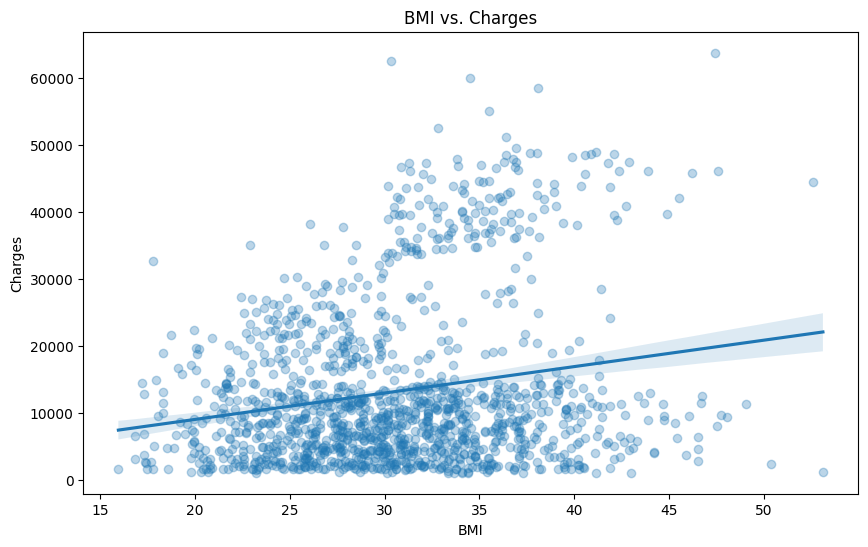

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new figure for the plot with a specified size
plt.figure(figsize=(10, 6))
# Generate a scatter plot with a regression line to show the relationship between BMI and charges
# 'scatter_kws={'alpha':0.3}' sets the transparency of the scatter points for better visualization of dense areas
sns.regplot(x='bmi', y='charges', data=df, scatter_kws={'alpha':0.3})
plt.title('BMI vs. Charges') # Set the title of the plot
plt.xlabel('BMI') # Set the label for the x-axis
plt.ylabel('Charges') # Set the label for the y-axis
plt.show() # Display the plot

### Visualizing the impact of Age on insurance charges

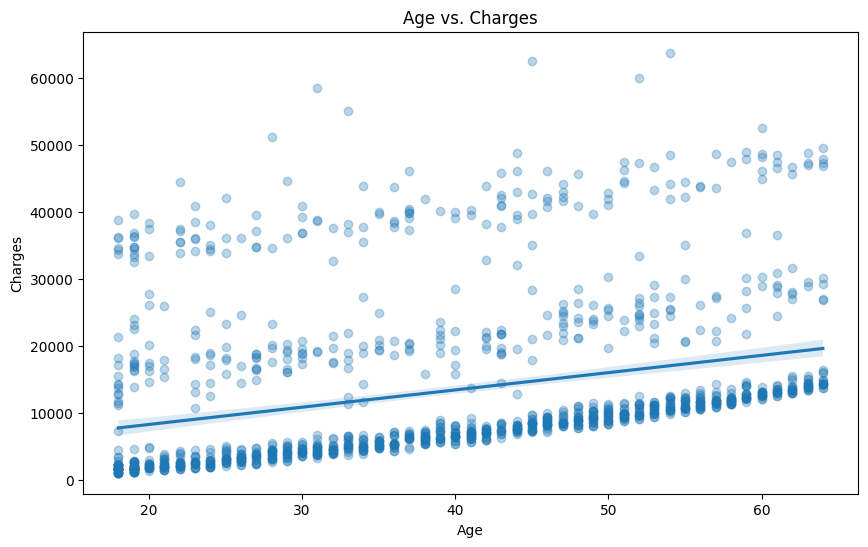

In [15]:
# Create a new figure for the plot with a specified size
plt.figure(figsize=(10, 6))
# Generate a scatter plot with a regression line to show the relationship between Age and charges
sns.regplot(x='age', y='charges', data=df, scatter_kws={'alpha':0.3})
plt.title('Age vs. Charges') # Set the title of the plot
plt.xlabel('Age') # Set the label for the x-axis
plt.ylabel('Charges') # Set the label for the y-axis
plt.show() # Display the plot

### Visualizing the impact of Smoking Status on insurance charges

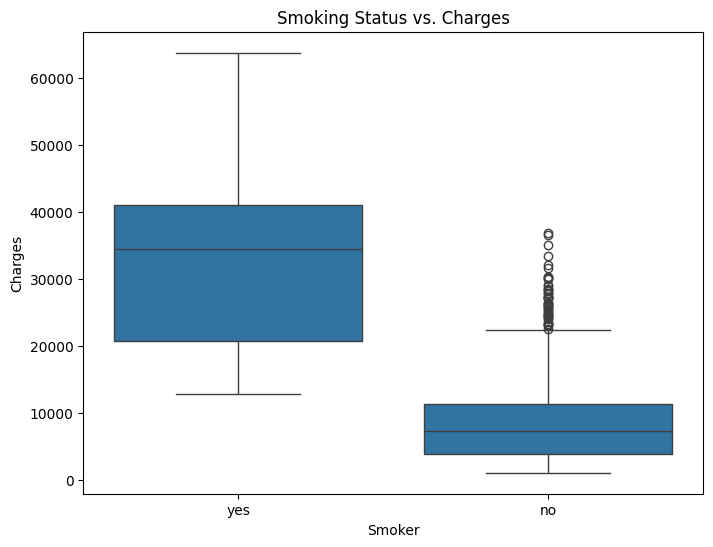

In [16]:
# Create a new figure for the plot with a specified size
plt.figure(figsize=(8, 6))
# Generate a box plot to visualize the distribution of charges based on smoking status
# Box plots are effective for comparing distributions of a numerical variable across different categories
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Smoking Status vs. Charges') # Set the title of the plot
plt.xlabel('Smoker') # Set the label for the x-axis
plt.ylabel('Charges') # Set the label for the y-axis
plt.show() # Display the plot

### Evaluate model performance using MAE and RMSE

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on the test set using the trained Linear Regression model
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
# MAE measures the average magnitude of the errors in a set of predictions, without considering their direction.
# It's the average of the absolute differences between prediction and actual observation.
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae:.2f}')

# Calculate Root Mean Squared Error (RMSE)
# RMSE is the square root of the average of squared errors. It gives higher weight to larger errors,
# making it sensitive to outliers. It's in the same unit as the target variable.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 4181.19
Root Mean Squared Error (RMSE): 5796.28


## Conclusion

This analysis successfully built and evaluated a Linear Regression model to predict medical insurance claim amounts based on personal data. The preprocessing involved one-hot encoding of categorical features such as `sex`, `smoker`, and `region`.

### Key Insights from Visualizations:
*   **BMI vs. Charges:** A positive correlation was observed between BMI and insurance charges, particularly for higher BMI values.
*   **Age vs. Charges:** Older individuals tend to incur higher insurance charges, indicating a positive correlation between age and medical costs.
*   **Smoking Status vs. Charges:** Smoking significantly impacts insurance charges, with smokers generally having much higher costs compared to non-smokers.

### Model Performance:
The Linear Regression model achieved the following evaluation metrics:
*   **Mean Absolute Error (MAE):** 4181.19
*   **Root Mean Squared Error (RMSE):** 5796.28

These metrics suggest that the model's predictions are, on average, off by approximately \$4181.19 from the actual charges. The RMSE further quantifies the magnitude of these errors, giving more weight to larger discrepancies. This provides a foundational understanding of the model's predictive capability, and further enhancements could be explored through more advanced modeling techniques or additional feature engineering.